# Notebook 4 – Introduction to Deep Learning and Neural Networks

In this notebook, we will:

- Understand what a **neural network** is and how it relates to ML.
- Learn the basic building blocks: **neurons**, **layers**, and **activation functions**.
- See, at a high level, how training works (loss, gradients, updates).
- Build a very small neural network with **TensorFlow/Keras** to connect ideas to code.

This will stay mostly conceptual, with minimal math and one short code demo.


## 1. From Machine Learning to Deep Learning

So far, we have:

- Worked with **tabular data**.
- Built a simple baseline model (logistic regression) for classification.

Deep learning is:

- A **subset of machine learning**.
- Uses multi-layer **neural networks** to learn complex patterns.
- Especially strong on **images, text, audio, and large datasets**.

Key differences (very high level):

- Classical ML:
  - Often needs a lot of **manual feature engineering**.
  - Works very well on smaller, structured datasets.
- Deep Learning:
  - Learns **features automatically** from raw data (pixels, words, signals).
  - Needs **more data** and **more compute**, but can reach very high performance.


## 2. Neurons: the basic building block

A neural network is made of many simple units called **neurons** (or nodes).

Conceptually, a single neuron does three things:

1. Takes some **inputs**: \(x_1, x_2, \dots, x_n\).
2. Multiplies each input by a **weight** and adds a **bias**.
3. Passes the result through an **activation function** to produce an output.

You can think of it as:

> input numbers → weighted sum → non-linear function → output number

Even though a single neuron is simple, when we **stack many of them**, we get powerful models that can approximate very complex functions.


## 3. Layers and network architecture

Neurons are organized into **layers**:

- **Input layer**: receives the raw features (e.g., hours_studied, previous_score, attendance, etc.).
- **Hidden layers**: perform intermediate computations and learn useful internal representations.
- **Output layer**: produces the final prediction (e.g., pass probability, class scores).

A simple feedforward neural network (also called a multilayer perceptron or MLP) looks like:

- Input → Dense layer → Dense layer → Output layer

Where each **Dense** layer is a fully connected layer: every neuron in one layer is connected to every neuron in the next.


## 4. Activation functions: adding non-linearity

If we only stacked linear operations (weighted sums), the entire network would still behave like a **single linear function**.

Activation functions introduce **non-linearity**, which allows neural networks to learn complex, curved decision boundaries.

Common activation functions:

- **ReLU** (Rectified Linear Unit): 
  - \( \text{ReLU}(z) = \max(0, z) \)
  - Very popular in hidden layers.
- **Sigmoid**:
  - Squashes values to the range (0, 1).
  - Often used in the output layer for binary classification (probability of class 1).
- **Softmax**:
  - Converts a vector of scores into probabilities that sum to 1.
  - Used in the output layer for multi-class classification.

In Keras, you specify them with strings like `"relu"`, `"sigmoid"`, `"softmax"` when defining layers.


## 5. How do neural networks learn?

At a high level, training a neural network involves:

1. **Forward pass**:
   - Pass input data through the network to get predictions.
2. **Loss calculation**:
   - Compare predictions to true labels using a **loss function** (e.g., binary cross-entropy, mean squared error).
3. **Backward pass (backpropagation)**:
   - Compute gradients of the loss with respect to each weight and bias.
4. **Parameter update**:
   - Use an **optimizer** (like SGD, Adam) to slightly update weights in the direction that reduces the loss.

This process repeats for many **epochs** (passes over the training data) until the model learns useful patterns.

You don’t need to implement backpropagation manually — frameworks like TensorFlow handle it for you.


## 6. TensorFlow/Keras: how we describe networks in code

Keras (inside TensorFlow) gives you a clean way to describe neural networks in Python.

Common patterns:

- Use a `Sequential` model when layers are stacked in a simple, linear way:
  - `model = keras.Sequential([...layers...])`
- Use `Dense` layers for fully connected networks on tabular data:
  - `layers.Dense(units=64, activation="relu")`
- Then:
  - `model.compile(loss=..., optimizer=..., metrics=[...])`
  - `model.fit(X_train, y_train, epochs=..., batch_size=...)`
  - `model.evaluate(X_test, y_test)`

We’ve already seen this pattern in a tiny way in Notebook 1.
Now we’ll do it again, but a bit more systematically.


# Imports and data

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create a synthetic student-like dataset
n = 200

data = {
    "student_id": np.arange(1, n + 1),
    "hours_studied": np.random.randint(0, 10, size=n).astype("float"),
    "previous_score": np.random.randint(30, 90, size=n).astype("float"),
    "attendance": np.random.randint(50, 100, size=n).astype("float"),
    "extra_classes": np.random.choice([0, 1], size=n).astype("float"),
    "final_score": np.random.randint(30, 95, size=n).astype("float"),
}

df = pd.DataFrame(data)

# Simple pass/fail label
df["passed"] = (df["final_score"] >= 50).astype(int)

df.head()


,student_id,hours_studied,previous_score,attendance,extra_classes,final_score,passed
0,1,6.0,51.0,74.0,1.0,64.0,1
1,2,3.0,40.0,73.0,1.0,35.0,0
2,3,7.0,77.0,62.0,0.0,76.0,1
3,4,4.0,45.0,56.0,0.0,54.0,1
4,5,6.0,62.0,85.0,0.0,39.0,0


# Prepare features and train–test split

In [2]:
feature_cols = ["hours_studied", "previous_score", "attendance", "extra_classes"]
target_col = "passed"

X = df[feature_cols].values.astype("float32")
y = df[target_col].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape


((160, 4), (40, 4))

# Build a small neural network

In [3]:
# Define a simple feedforward neural network with Keras
model = keras.Sequential(
    [
        layers.Input(shape=(len(feature_cols),)),
        layers.Dense(16, activation="relu"),  # hidden layer 1
        layers.Dense(8, activation="relu"),   # hidden layer 2
        layers.Dense(1, activation="sigmoid") # output layer for binary classification
    ]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

# Compile the model

In [4]:
model.compile(
    loss="binary_crossentropy",  # suitable for binary labels
    optimizer="adam",
    metrics=["accuracy"],
)


# Train the model

In [6]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,  # hold out part of train as validation
    epochs=30,
    batch_size=16,
    verbose=0,             # set to 1 to show training logs
)

print("Training complete.")


Training complete.


# Evaluate on test data

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.50


# Look at training curves

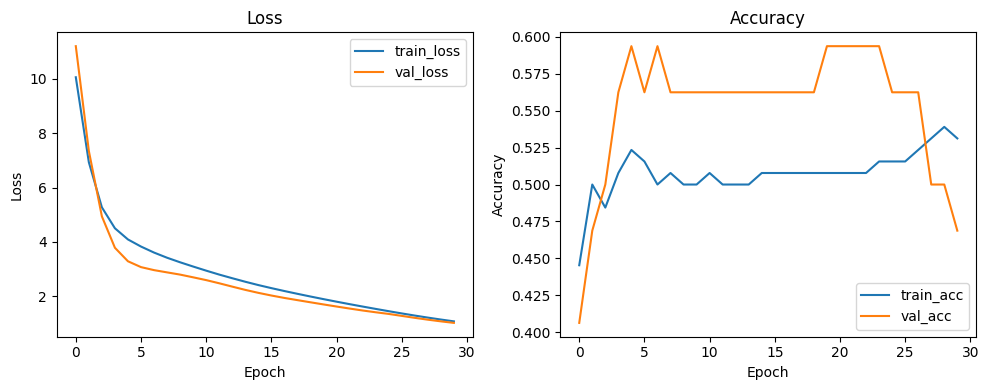

In [8]:
import matplotlib.pyplot as plt

history_dict = history.history

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict["loss"], label="train_loss")
plt.plot(history_dict["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["accuracy"], label="train_acc")
plt.plot(history_dict["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


### What do these curves tell us?

From the loss and accuracy plots (if you ran them), you can usually see:

- **Training loss** going down, **training accuracy** going up.
- **Validation loss/accuracy** showing how well the model generalizes.

Patterns to watch for:

- Training accuracy keeps improving but validation accuracy stops or gets worse:
  - The model may be **overfitting**.
- Both training and validation accuracy are low:
  - The model is **underfitting** (too simple, not enough training, or data not informative enough).

We will not do heavy tuning here; the goal is to see:

> Same pipeline as classical ML, but the **model box** is now a small neural network instead of a logistic regression.


## 7. Summary of this notebook

In this notebook, you:

- Learned the basic ideas behind **neurons**, **layers**, and **activation functions**.
- Saw how neural networks are trained using:
  - Forward pass
  - Loss calculation
  - Backpropagation
  - Parameter updates
- Used **TensorFlow/Keras** to:
  - Define a small feedforward neural network.
  - Train it on a tabular dataset of students.
  - Evaluate its performance on a test set.

Conceptually, this is very similar to the classical ML pipeline:

1. Prepare data (features + labels).
2. Split into train and test sets.
3. Choose a model (logistic regression vs neural network).
4. Train and evaluate.

In the next notebook, we’ll go even more “TensorFlow‑native” for tabular data:
- Use Keras preprocessing or input pipelines.
- Experiment a bit more with network architecture and evaluation.
